### YOLO Algorithm

Reference: https://www.geeksforgeeks.org/computer-vision/object-detection-with-yolo-and-opencv/

The YOLO (You Only Look Once) algorithm is a popular object detection method that is known for its speed and accuracy. It works by dividing the input image into a grid and predicting bounding boxes and class probabilities for each grid cell. The algorithm processes the entire image in one pass, making it efficient for real-time applications.

YOLO is widely used in various applications such as surveillance, autonomous driving, and image recognition. It has undergone several iterations, with YOLOv4 and YOLOv5 being some of the latest versions that offer improved performance and accuracy.

In [9]:
!pip install opencv-python ultralytics

In [10]:
import cv2
import random
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

Load the YOLO model and perform object detection on an image

In [11]:
yolo = YOLO("yolov8s.pt")

Get unique colors for each class

In [12]:
def getColours(cls_num):
    random.seed(cls_num)
    return tuple(random.randint(0, 255) for _ in range(3))

Load the video and perform object detection on each frame

In [13]:
video_path = "sample.mp4"
videoCap = cv2.VideoCapture(video_path)
print("Video loaded successfully")

Video loaded successfully


We will feed the video to the system and it will check for objects in each frame and draw bounding boxes around them. The colors of the bounding boxes will be unique for each class of object detected.


0: 384x640 16 cars, 641.2ms
Speed: 2.3ms preprocess, 641.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


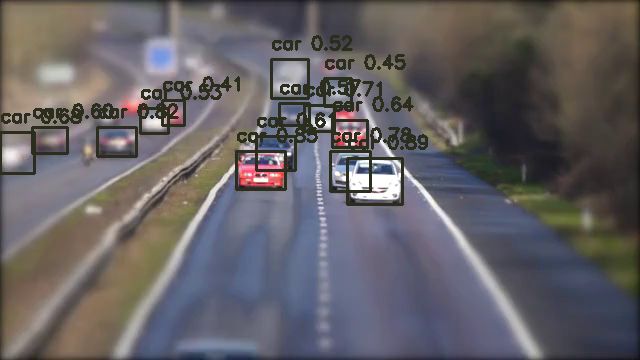


0: 384x640 1 person, 15 cars, 562.7ms
Speed: 5.3ms preprocess, 562.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


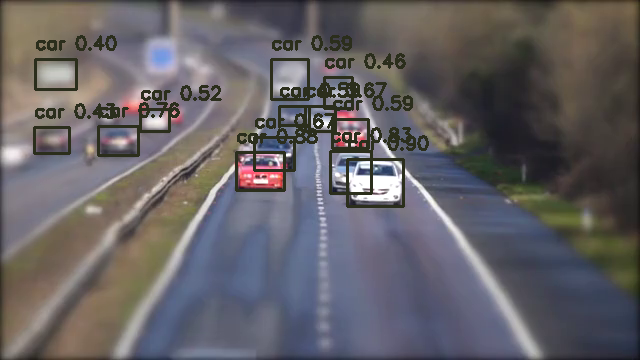


0: 384x640 1 person, 16 cars, 1 bus, 481.7ms
Speed: 2.4ms preprocess, 481.7ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


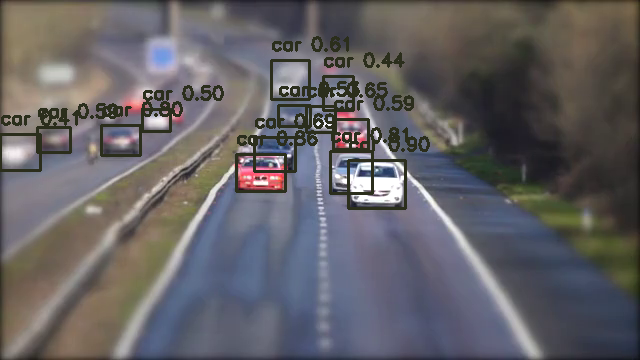


0: 384x640 15 cars, 1 bus, 815.7ms
Speed: 2.7ms preprocess, 815.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


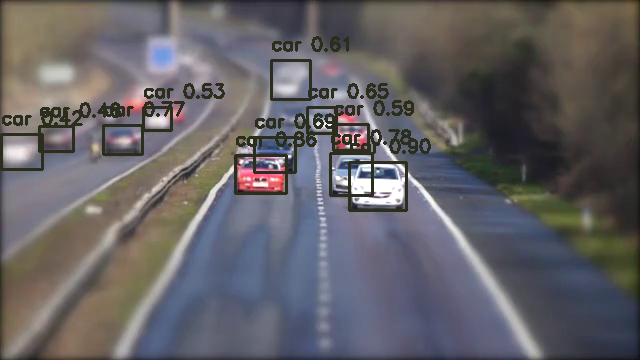


0: 384x640 15 cars, 1085.4ms
Speed: 2.5ms preprocess, 1085.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


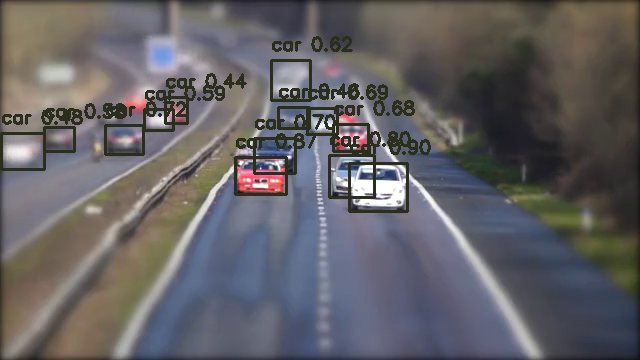


0: 384x640 15 cars, 1 bus, 1015.5ms
Speed: 2.3ms preprocess, 1015.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


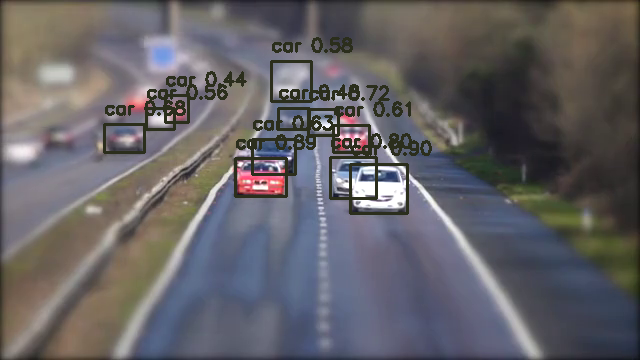


0: 384x640 15 cars, 1032.7ms
Speed: 4.0ms preprocess, 1032.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


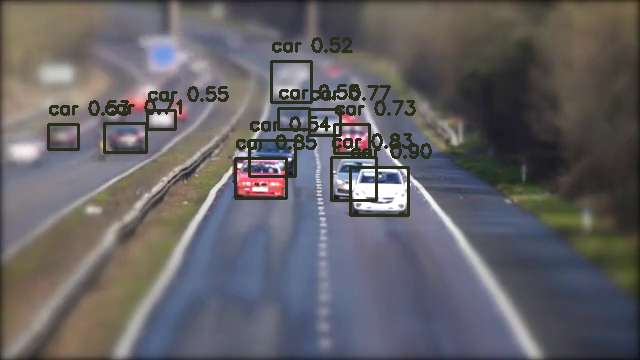


0: 384x640 15 cars, 842.6ms
Speed: 4.1ms preprocess, 842.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


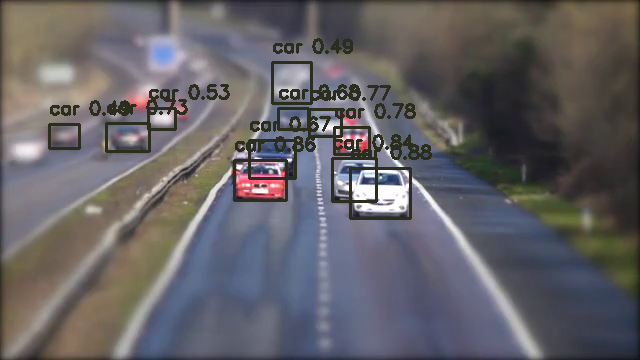


0: 384x640 17 cars, 1503.5ms
Speed: 6.2ms preprocess, 1503.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


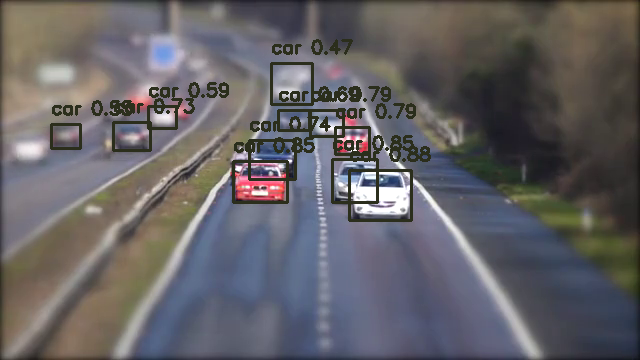


0: 384x640 16 cars, 1 bus, 593.9ms
Speed: 2.0ms preprocess, 593.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


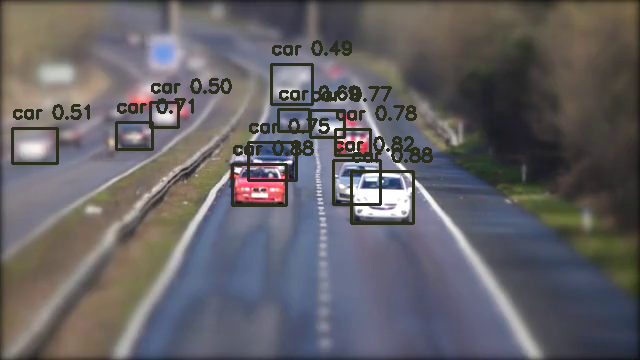


0: 384x640 15 cars, 646.0ms
Speed: 1.9ms preprocess, 646.0ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


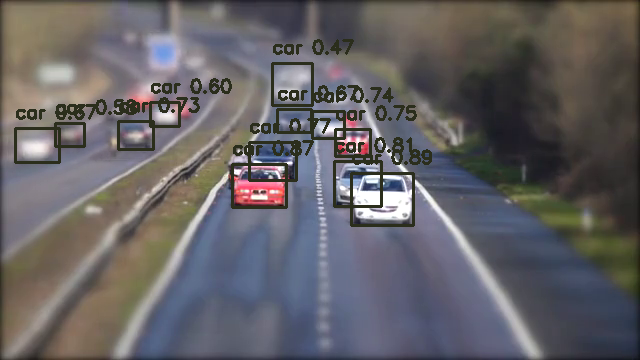


0: 384x640 15 cars, 689.6ms
Speed: 3.5ms preprocess, 689.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


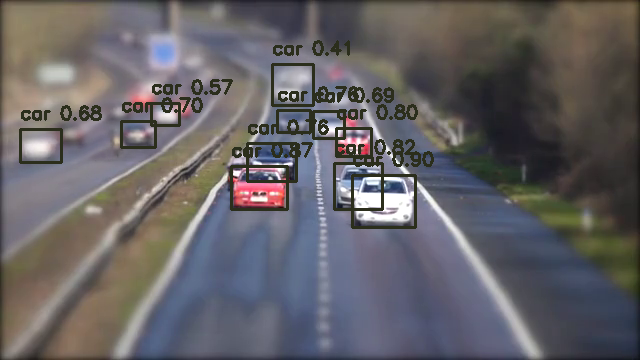


0: 384x640 1 person, 15 cars, 658.2ms
Speed: 2.0ms preprocess, 658.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


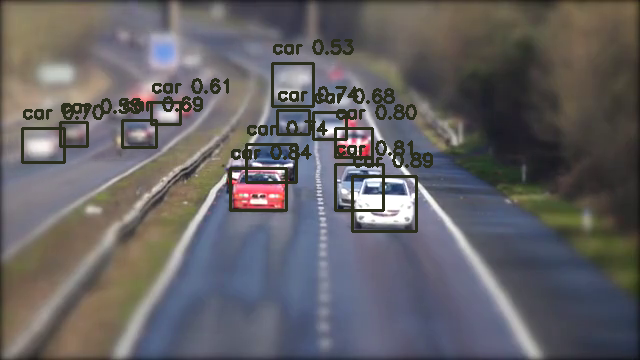


0: 384x640 15 cars, 1 bus, 494.3ms
Speed: 3.0ms preprocess, 494.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


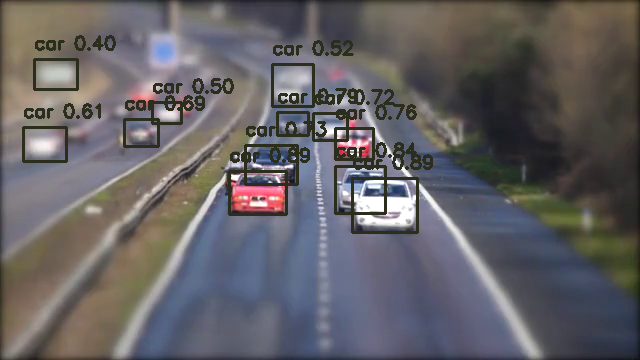


0: 384x640 17 cars, 481.3ms
Speed: 1.9ms preprocess, 481.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


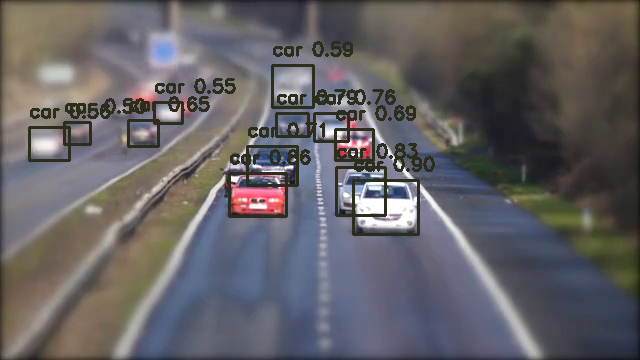


0: 384x640 15 cars, 510.5ms
Speed: 1.9ms preprocess, 510.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


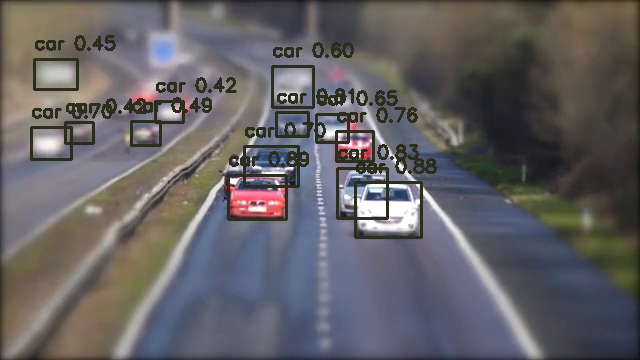


0: 384x640 15 cars, 501.4ms
Speed: 4.0ms preprocess, 501.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


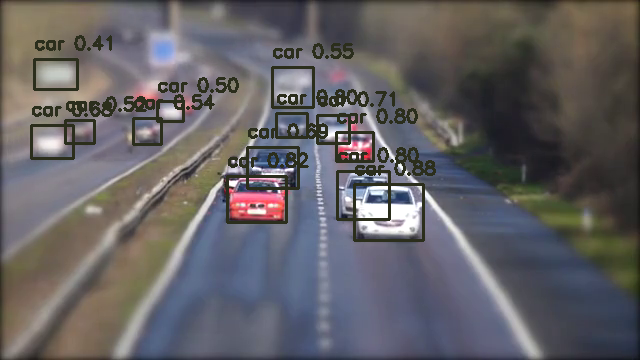


0: 384x640 16 cars, 523.0ms
Speed: 2.0ms preprocess, 523.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


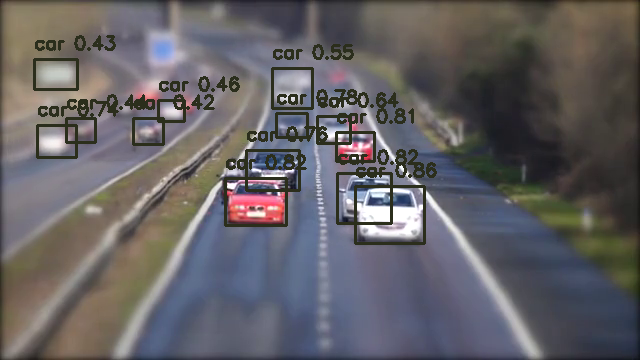


0: 384x640 15 cars, 514.8ms
Speed: 1.9ms preprocess, 514.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


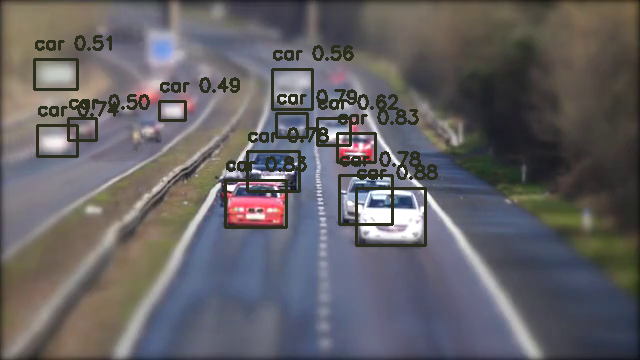


0: 384x640 15 cars, 543.3ms
Speed: 2.1ms preprocess, 543.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


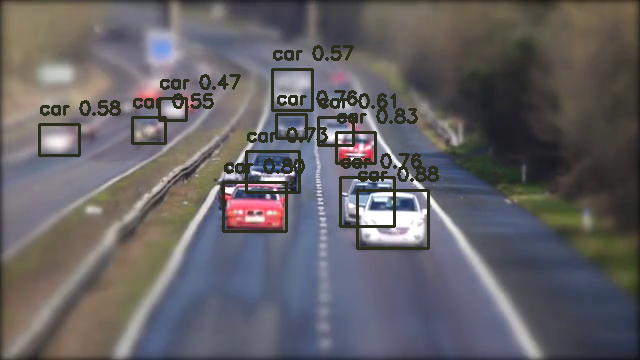


0: 384x640 16 cars, 560.8ms
Speed: 1.9ms preprocess, 560.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


In [14]:
frame_count = 0

while True:
    ret, frame = videoCap.read()
    if not ret:
        break
    results = yolo.track(frame, stream=True)

    for result in results:
        class_names = result.names
        for box in result.boxes:
            if box.conf[0] > 0.4:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                class_name = class_names[cls]
                conf = float(box.conf[0])
                colour = getColours(cls)
                cv2.rectangle(frame, (x1, y1), (x2, y2), colour, 2)
                cv2.putText(frame, f"{class_name} {conf:.2f}",
                            (x1, max(y1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX,
                            0.6, colour, 2)

    if frame_count < 20:
        cv2_imshow(frame)
    else:
        break

    frame_count += 1

videoCap.release()